# ДЗ: ITSM / Customer Support Ticket Routing (Multi-task NLP)

## Цель
Построить модель, которая по тексту тикета предсказывает:
- **queue** (52 класса) — основная задача (маршрутизация)
- **priority** (5 классов)
- **type** (5 классов): `Incident / Request / Problem / Change / Unknown`  
  где `Unknown` = отсутствующая разметка `type`.

### Подходы
1. **TF-IDF + SGDClassifier** (baseline)
2. **Word2Vec + SGDClassifier**
3. **XLM-RoBERTa**

### Итоговая метрика
```
Score = 0.70 × MacroF1(queue) + 0.15 × Acc(priority) + 0.15 × Acc(type)
```

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Данные

In [2]:
DATASET = "Tobi-Bueck/customer-support-tickets"
ds = load_dataset(DATASET)
df_full = ds["train"].to_pandas()

DATA_DIR = Path("data")
train_idx = np.loadtxt(DATA_DIR / "train_idx.txt", dtype=np.int64)
val_idx = np.loadtxt(DATA_DIR / "val_idx.txt", dtype=np.int64)
test_idx = np.loadtxt(DATA_DIR / "test_idx.txt", dtype=np.int64)

df_train = df_full.iloc[train_idx].copy().reset_index(drop=True)
df_val = df_full.iloc[val_idx].copy().reset_index(drop=True)
df_test = df_full.iloc[test_idx].copy().reset_index(drop=True)

for d in [df_train, df_val, df_test]:
    d["type"] = d["type"].fillna("Unknown")

def make_text(df):
    return (df["subject"].fillna("") + " " + df["body"].fillna("")).astype(str)

df_train["text"] = make_text(df_train)
df_val["text"] = make_text(df_val)
df_test["text"] = make_text(df_test)

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
print(f"Columns: {list(df_full.columns)}")
df_train.head()

README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Train: 49412, Val: 6176, Test: 6177
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None,"Account Disruption Dear Customer Support Team,..."
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None,Query About Smart Home System Integration Feat...
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None,Inquiry Regarding Invoice Details Dear Custome...
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None,Question About Marketing Agency Software Compa...


---
## 2. EDA (net blin voda)

In [3]:
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 9
colors = {"main": "#2E86AB", "accent": "#A23B72", "neutral": "#F18F01"}

In [4]:
print("Пропуски")
for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    miss = df[["subject", "body", "queue", "priority", "type"]].isna().mean()
    print(f"\n{name}:")
    if miss.any():
        print(miss[miss > 0].to_string())
    else:
        print("  No missing values in key columns")

Пропуски

train:
subject    0.086376
body       0.000040

val:
subject    0.081768

test:
subject    0.085155


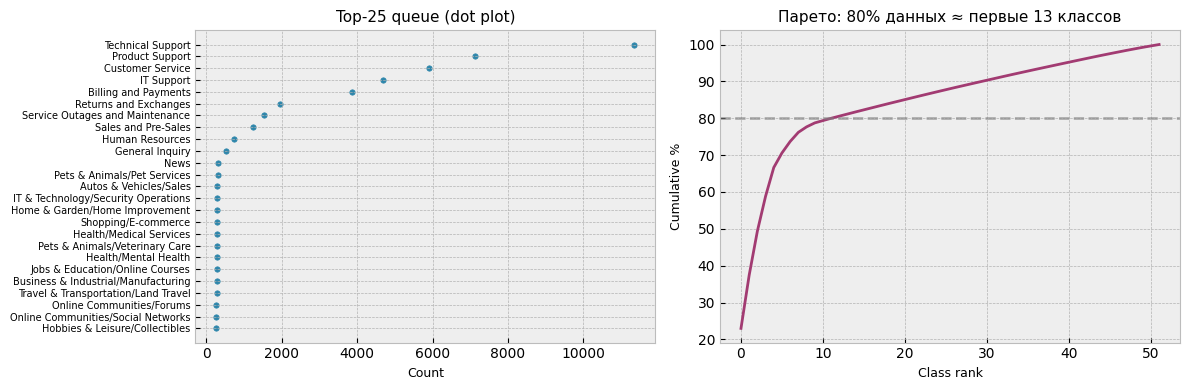

In [5]:
q_stats = df_train["queue"].value_counts().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(q_stats.values[:25], range(25), c=colors["main"], s=15)
ax1.set_yticks(range(25))
ax1.set_yticklabels(q_stats.index[:25], fontsize=7)
ax1.set_xlabel("Count")
ax1.set_title("Top-25 queue (dot plot)")
ax1.invert_yaxis()

cumsum = q_stats.cumsum() / q_stats.sum() * 100
ax2.plot(cumsum.values, color=colors["accent"])
ax2.axhline(80, ls="--", color="gray", alpha=0.6)
ax2.set_xlabel("Class rank")
ax2.set_ylabel("Cumulative %")
ax2.set_title("Парето: 80% данных ≈ первые {:.0f} классов".format(
    np.argmax(cumsum >= 80) + 1))

plt.tight_layout()
plt.show()

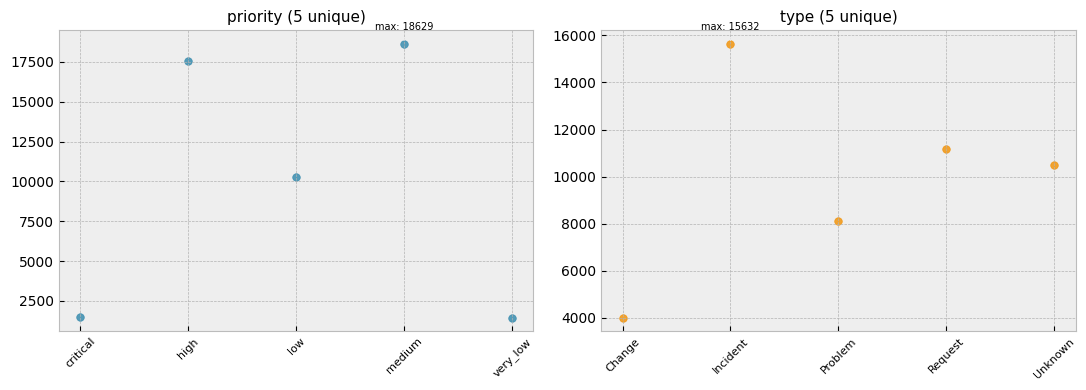

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, clr in zip(axes, ["priority", "type"], [colors["main"], colors["neutral"]]):
    vc = df_train[col].value_counts().sort_index()
    ax.scatter(vc.index.astype(str), vc.values, c=clr, s=30, alpha=0.8)
    ax.set_title(f"{col} ({vc.nunique()} unique)")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    mx_idx = vc.idxmax()
    ax.annotate(f"max: {vc.max()}",
                xy=(str(mx_idx), vc.max()),
                xytext=(0, 10), textcoords="offset points",
                fontsize=7, ha="center", arrowprops=dict(arrowstyle="->", lw=0.5))

plt.tight_layout()
plt.show()

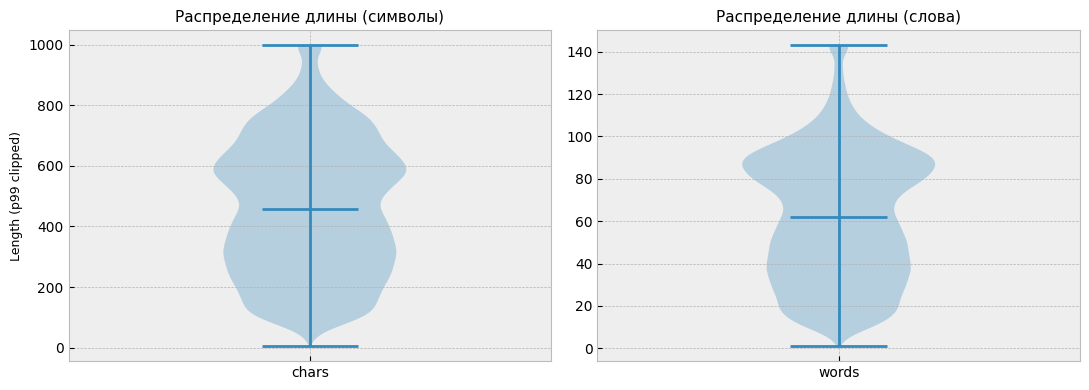

Chars: μ=464, med=459, p99=998
Words: μ=62, med=62, p99=143


In [7]:
txt = df_train["text"]
char_len = txt.str.len()
word_len = txt.str.split().str.len()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.violinplot([char_len.clip(upper=char_len.quantile(0.99))],
               positions=[1], widths=0.8, showmedians=True)
ax1.set_xlim(0, 2)
ax1.set_xticks([1])
ax1.set_xticklabels(["chars"])
ax1.set_ylabel("Length (p99 clipped)")
ax1.set_title("Распределение длины (символы)")

ax2.violinplot([word_len.clip(upper=word_len.quantile(0.99))],
               positions=[1], widths=0.8, showmedians=True)
ax2.set_xlim(0, 2)
ax2.set_xticks([1])
ax2.set_xticklabels(["words"])
ax2.set_title("Распределение длины (слова)")

plt.tight_layout()
plt.show()

print(f"Chars: μ={char_len.mean():.0f}, med={char_len.median():.0f}, p99={char_len.quantile(0.99):.0f}")
print(f"Words: μ={word_len.mean():.0f}, med={word_len.median():.0f}, p99={word_len.quantile(0.99):.0f}")

In [8]:
summary = pd.DataFrame({
    "priority_med_words": df_train.groupby("priority")["text"].apply(lambda x: x.str.split().str.len().median()),
    "type_med_words": df_train.groupby("type")["text"].apply(lambda x: x.str.split().str.len().median()),
    "queue_count": df_train["queue"].value_counts()
}).fillna(0)

print("Медиана слов по приоритету:")
print(summary["priority_med_words"].sort_index().to_string())

print("\nТоп-5 самых частых queue:")
print(summary["queue_count"].head().to_string())

Медиана слов по приоритету:
Arts & Entertainment/Movies                0.0
Arts & Entertainment/Music                 0.0
Autos & Vehicles/Maintenance               0.0
Autos & Vehicles/Sales                     0.0
Beauty & Fitness/Cosmetics                 0.0
Beauty & Fitness/Fitness Training          0.0
Billing and Payments                       0.0
Books & Literature/Fiction                 0.0
Books & Literature/Non-Fiction             0.0
Business & Industrial/Manufacturing        0.0
Change                                     0.0
Customer Service                           0.0
Finance/Investments                        0.0
Finance/Personal Finance                   0.0
Food & Drink/Groceries                     0.0
Food & Drink/Restaurants                   0.0
Games                                      0.0
General Inquiry                            0.0
Health/Medical Services                    0.0
Health/Mental Health                       0.0
Hobbies & Leisure/Collectibles  

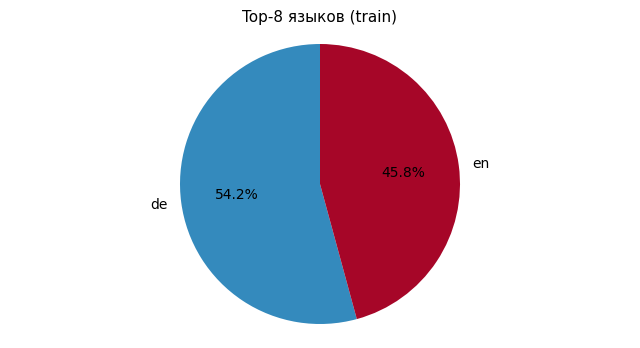

In [9]:
if "language" in df_train:
    lang = df_train["language"].fillna("unknown").value_counts()
    plt.figure(figsize=(8, 4))
    plt.pie(lang.values[:8], labels=lang.index[:8], autopct="%1.1f%%", startangle=90)
    plt.title("Top-8 языков (train)")
    plt.axis("equal")
    plt.show()

---
## 2. Пара вспомогателных функций

In [10]:
from sklearn.metrics import f1_score, accuracy_score

def compute_score(y_queue, pred_queue, y_priority, pred_priority, y_type, pred_type):

    mf1_q = f1_score(y_queue, pred_queue, average="macro")
    acc_q = accuracy_score(y_queue, pred_queue)
    acc_p = accuracy_score(y_priority, pred_priority)
    acc_t = accuracy_score(y_type, pred_type)

    final_score = 0.70 * mf1_q + 0.15 * acc_p + 0.15 * acc_t

    return {
        "MacroF1(queue)": mf1_q,
        "Acc(queue)": acc_q,
        "Acc(priority)": acc_p,
        "Acc(type)": acc_t,
        "Score": final_score,
    }


def print_results(results, model_name="Model"):

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    for metric, value in results.items():
        print(f"  {metric:20s}: {value:.4f}")
    print(f"{'='*55}")


def confidence_coverage_analysis(y_true, y_pred, confidences, metric_fn, metric_name="Metric"):

    sorted_idx = np.argsort(-confidences)

    coverage_steps = np.arange(0.05, 1.01, 0.05)
    records = []

    for cov in coverage_steps:
        n_samples = max(1, int(len(y_true) * cov))
        selected_idx = sorted_idx[:n_samples]

        metric_val = metric_fn(np.array(y_true)[selected_idx], np.array(y_pred)[selected_idx])

        records.append({
            "coverage": round(cov, 2),
            "n_samples": n_samples,
            metric_name: round(metric_val, 4),
            "min_confidence": round(float(confidences[sorted_idx[n_samples - 1]]), 4),
        })

    return pd.DataFrame(records)


def plot_confidence_curve(conf_df, metric_name, title, color="steelblue"):

    fig, ax_main = plt.subplots(figsize=(10, 5))

    ax_main.plot(
        conf_df["coverage"],
        conf_df[metric_name],
        "o-",
        color=color,
        linewidth=2,
        markersize=5,
        label=metric_name
    )
    ax_main.set_xlabel("Coverage")
    ax_main.set_ylabel(metric_name, color=color)
    ax_main.set_title(title)
    ax_main.grid(True, alpha=0.3)

    ax_conf = ax_main.twinx()
    ax_conf.plot(
        conf_df["coverage"],
        conf_df["min_confidence"],
        "s--",
        color="gray",
        alpha=0.6,
        linewidth=1,
        markersize=4,
        label="Min confidence"
    )
    ax_conf.set_ylabel("Порог уверенности", color="gray")

    lines_1, labels_1 = ax_main.get_legend_handles_labels()
    lines_2, labels_2 = ax_conf.get_legend_handles_labels()
    ax_main.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower right")

    plt.tight_layout()
    plt.show()




---
## 3.1 Пробуем разные модели

In [11]:
all_model_results = {}
all_conf_curves = {}

### 3.1 TF-IDF + SGDClassifier

In [12]:
tfidf = TfidfVectorizer(
    max_features=200_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(df_train["text"])
X_val_tfidf = tfidf.transform(df_val["text"])
X_test_tfidf = tfidf.transform(df_test["text"])

In [13]:
tfidf_preds = {}
tfidf_probas = {}

for target in ["queue", "priority", "type"]:
    print(f"Training SGDClassifier for '{target}'...")
    base = SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=100,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf = CalibratedClassifierCV(base, cv=3, n_jobs=-1)
    clf.fit(X_train_tfidf, df_train[target].astype(str))

    tfidf_preds[target] = clf.predict(X_test_tfidf)
    tfidf_probas[target] = clf.predict_proba(X_test_tfidf)

    acc = accuracy_score(df_test[target].astype(str), tfidf_preds[target])
    if target == "queue":
        mf1 = f1_score(
            df_test[target].astype(str), tfidf_preds[target], average="macro"
        )
        print(f"  {target}: Acc={acc:.4f}, MacroF1={mf1:.4f}")
    else:
        print(f"  {target}: Acc={acc:.4f}")

tfidf_results = compute_score(
    df_test["queue"].astype(str),
    tfidf_preds["queue"],
    df_test["priority"].astype(str),
    tfidf_preds["priority"],
    df_test["type"].astype(str),
    tfidf_preds["type"],
)
print_results(tfidf_results, "TF-IDF + SGDClassifier")
all_model_results["TF-IDF + SGD"] = tfidf_results

Training SGDClassifier for 'queue'...
  queue: Acc=0.5221, MacroF1=0.6936
Training SGDClassifier for 'priority'...
  priority: Acc=0.5707
Training SGDClassifier for 'type'...
  type: Acc=0.8452

  TF-IDF + SGDClassifier
  MacroF1(queue)      : 0.6936
  Acc(queue)          : 0.5221
  Acc(priority)       : 0.5707
  Acc(type)           : 0.8452
  Score               : 0.6979


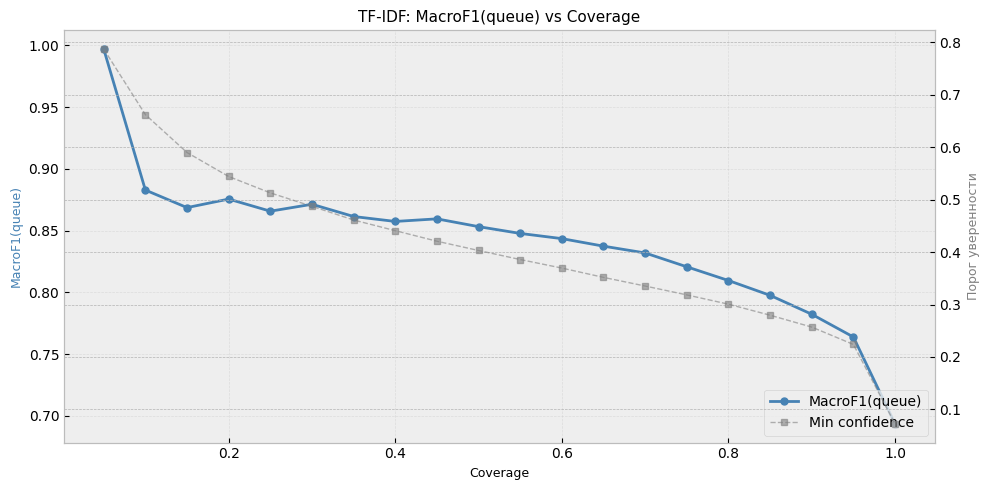

In [14]:
tfidf_conf = confidence_coverage_analysis(
    df_test["queue"].astype(str).values,
    tfidf_preds["queue"],
    np.max(tfidf_probas["queue"], axis=1),
    lambda y, p: f1_score(y, p, average="macro"),
    "MacroF1(queue)",
)
all_conf_curves["TF-IDF + SGD"] = tfidf_conf

plot_confidence_curve(
    tfidf_conf,
    "MacroF1(queue)",
    "TF-IDF: MacroF1(queue) vs Coverage",
    color="steelblue",
)

---
### 3.2 Word2Vec + SGDClassifier

In [15]:
# !pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.3 MB/s eta 0:00:00


In [16]:
from gensim.models import Word2Vec
from tqdm import tqdm


def simple_tokenize(text):
    import re

    return re.findall(r"\w+", text.lower())


sentences_train = [simple_tokenize(t) for t in df_train["text"]]

w2v = Word2Vec(
    sentences_train,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    epochs=15,
    seed=RANDOM_STATE,
)
print(f"Word2Vec vocabulary: {len(w2v.wv)} words, dim={w2v.wv.vector_size}")

Word2Vec vocabulary: 23937 words, dim=300


In [17]:
def text_to_vec(text, model, dim=300):
    tokens = simple_tokenize(text)
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)


print("Vectorizing train...")
X_train_w2v = np.array([text_to_vec(t, w2v) for t in tqdm(df_train["text"])])
print("Vectorizing val...")
X_val_w2v = np.array([text_to_vec(t, w2v) for t in tqdm(df_val["text"])])
print("Vectorizing test...")
X_test_w2v = np.array([text_to_vec(t, w2v) for t in tqdm(df_test["text"])])

print(f"W2V features shape: {X_train_w2v.shape}")

Vectorizing train...


100%|██████████| 49412/49412 [00:08<00:00, 5915.25it/s]


Vectorizing val...


100%|██████████| 6176/6176 [00:00<00:00, 6822.75it/s]


Vectorizing test...


100%|██████████| 6177/6177 [00:00<00:00, 6873.01it/s]

W2V features shape: (49412, 300)


In [18]:
w2v_preds = {}
w2v_probas = {}

for target in ["queue", "priority", "type"]:
    print(f"Training SGDClassifier (W2V) for '{target}'...")
    base = SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=100,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf = CalibratedClassifierCV(base, cv=3, n_jobs=-1)
    clf.fit(X_train_w2v, df_train[target].astype(str))

    w2v_preds[target] = clf.predict(X_test_w2v)
    w2v_probas[target] = clf.predict_proba(X_test_w2v)

    acc = accuracy_score(df_test[target].astype(str), w2v_preds[target])
    if target == "queue":
        mf1 = f1_score(df_test[target].astype(str), w2v_preds[target], average="macro")
        print(f"  {target}: Acc={acc:.4f}, MacroF1={mf1:.4f}")
    else:
        print(f"  {target}: Acc={acc:.4f}")

w2v_results = compute_score(
    df_test["queue"].astype(str),
    w2v_preds["queue"],
    df_test["priority"].astype(str),
    w2v_preds["priority"],
    df_test["type"].astype(str),
    w2v_preds["type"],
)
print_results(w2v_results, "Word2Vec + SGDClassifier")
all_model_results["Word2Vec + SGD"] = w2v_results

Training SGDClassifier (W2V) for 'queue'...
  queue: Acc=0.3437, MacroF1=0.1936
Training SGDClassifier (W2V) for 'priority'...
  priority: Acc=0.4917
Training SGDClassifier (W2V) for 'type'...
  type: Acc=0.8213

  Word2Vec + SGDClassifier
  MacroF1(queue)      : 0.1936
  Acc(queue)          : 0.3437
  Acc(priority)       : 0.4917
  Acc(type)           : 0.8213
  Score               : 0.3324


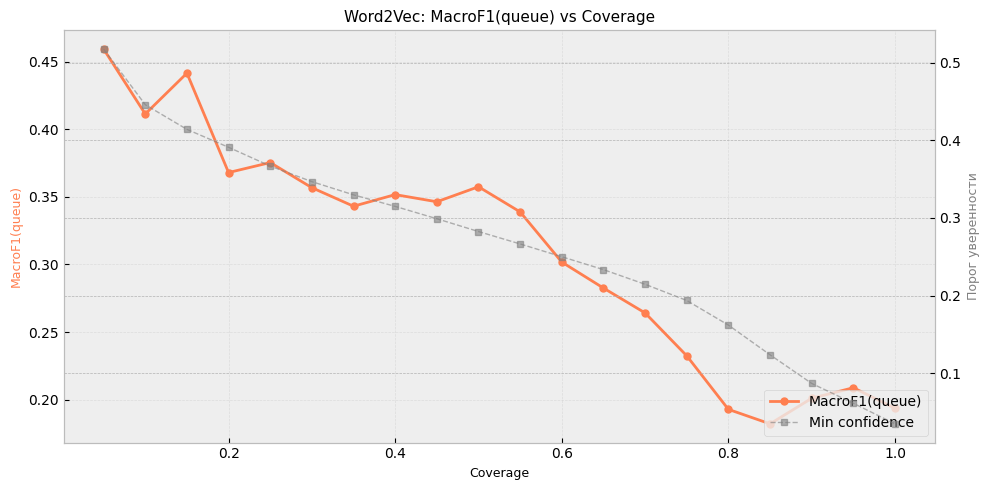

In [19]:
w2v_conf = confidence_coverage_analysis(
    df_test["queue"].astype(str).values,
    w2v_preds["queue"],
    np.max(w2v_probas["queue"], axis=1),
    lambda y, p: f1_score(y, p, average="macro"),
    "MacroF1(queue)",
)
all_conf_curves["Word2Vec + SGD"] = w2v_conf

plot_confidence_curve(
    w2v_conf, "MacroF1(queue)", "Word2Vec: MacroF1(queue) vs Coverage", color="coral"
)

---
## 3.3 XLM-BERT

In [20]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

MODEL_NAME = "xlm-roberta-base"
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 3
LR = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [22]:
label_encoders = {}
for target in ["queue", "priority", "type"]:
    le = LabelEncoder()
    le.fit(df_train[target].astype(str))
    label_encoders[target] = le
    for d in [df_train, df_val, df_test]:
        d[f"{target}_enc"] = le.transform(d[target].astype(str))

num_classes = {t: len(le.classes_) for t, le in label_encoders.items()}
print(f"Number of classes: {num_classes}")


class TicketDataset(Dataset):
    def __init__(self, texts, labels_dict, tokenizer, max_len):
        self.texts = texts
        self.labels = labels_dict
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels_queue"] = torch.tensor(self.labels["queue"][idx], dtype=torch.long)
        item["labels_priority"] = torch.tensor(
            self.labels["priority"][idx], dtype=torch.long
        )
        item["labels_type"] = torch.tensor(self.labels["type"][idx], dtype=torch.long)
        return item



def make_labels_dict(df):
    return {t: df[f"{t}_enc"].values for t in ["queue", "priority", "type"]}


train_ds = TicketDataset(
    df_train["text"].tolist(), make_labels_dict(df_train), tokenizer, MAX_LEN
)
val_ds = TicketDataset(
    df_val["text"].tolist(), make_labels_dict(df_val), tokenizer, MAX_LEN
)
test_ds = TicketDataset(
    df_test["text"].tolist(), make_labels_dict(df_test), tokenizer, MAX_LEN
)

Number of classes: {'queue': 52, 'priority': 5, 'type': 5}


In [23]:
class MultitaskTicketModel(nn.Module):
    def __init__(self, model_name, n_queue, n_priority, n_type, dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(
            model_name,
            attn_implementation="sdpa",
        )
        h = self.backbone.config.hidden_size
        self.drop = nn.Dropout(dropout)
        self.head_queue = nn.Linear(h, n_queue)
        self.head_priority = nn.Linear(h, n_priority)
        self.head_type = nn.Linear(h, n_type)
        self.config = self.backbone.config

    def forward(
        self,
        input_ids,
        attention_mask,
        labels_queue=None,
        labels_priority=None,
        labels_type=None,
        **kwargs,
    ):

        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask, **kwargs)


        cls_out = self.drop(out.last_hidden_state[:, 0, :])

        lq = self.head_queue(cls_out)
        lp = self.head_priority(cls_out)
        lt = self.head_type(cls_out)

        loss = None
        if labels_queue is not None:
            ce = nn.CrossEntropyLoss()
            loss = (
                0.70 * ce(lq.float(), labels_queue)
                + 0.15 * ce(lp.float(), labels_priority)
                + 0.15 * ce(lt.float(), labels_type)
            )

        return {
            "loss": loss,
            "logits_queue": lq,
            "logits_priority": lp,
            "logits_type": lt,
        }



class MultitaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss


model = MultitaskTicketModel(
    MODEL_NAME,
    num_classes["queue"],
    num_classes["priority"],
    num_classes["type"],
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
training_args = TrainingArguments(

    output_dir="./xlm_roberta_multitask_ckpt",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=4,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    dataloader_num_workers=0,
    report_to="none",
    seed=RANDOM_STATE,
    remove_unused_columns=False,
)

trainer = MultitaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()
print("Training complete!")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,1.261159,1.203215
2,1.077077,1.071972
3,0.994671,1.036949


Training complete!


In [25]:
model.eval()
model.to(device)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0
)

test_preds_t = {t: [] for t in ["queue", "priority", "type"]}
test_probas_t = {t: [] for t in ["queue", "priority", "type"]}

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test evaluation"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = model(input_ids, attention_mask)
        for t in ["queue", "priority", "type"]:
            logits = outputs[f"logits_{t}"].float()
            probs = torch.softmax(logits, dim=1)
            test_preds_t[t].extend(logits.argmax(dim=1).cpu().numpy())
            test_probas_t[t].extend(probs.cpu().numpy())

transformer_preds = {}
transformer_probas = {}
for t in ["queue", "priority", "type"]:
    transformer_preds[t] = label_encoders[t].inverse_transform(test_preds_t[t])
    transformer_probas[t] = np.array(test_probas_t[t])

transformer_results = compute_score(
    df_test["queue"].astype(str),
    transformer_preds["queue"],
    df_test["priority"].astype(str),
    transformer_preds["priority"],
    df_test["type"].astype(str),
    transformer_preds["type"],
)
print_results(transformer_results, "XLM-RoBERTa Multitask")
all_model_results["XLM-RoBERTa Multitask"] = transformer_results

Test evaluation: 100%|██████████| 387/387 [00:23<00:00, 16.17it/s]



  XLM-RoBERTa Multitask
  MacroF1(queue)      : 0.8306
  Acc(queue)          : 0.5741
  Acc(priority)       : 0.5320
  Acc(type)           : 0.8409
  Score               : 0.7874


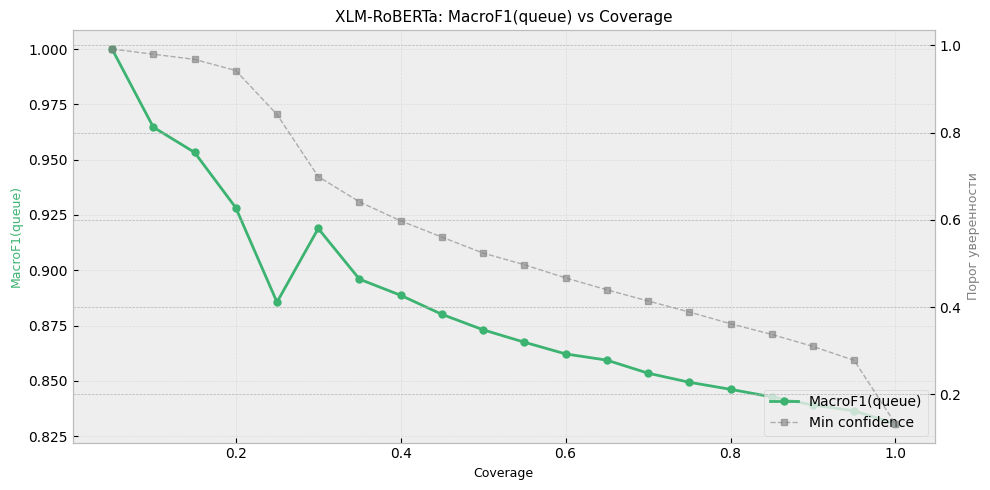

In [26]:
transformer_conf = confidence_coverage_analysis(
    df_test["queue"].astype(str).values,
    transformer_preds["queue"],
    np.max(transformer_probas["queue"], axis=1),
    lambda y, p: f1_score(y, p, average="macro"),
    "MacroF1(queue)",
)
all_conf_curves["XLM-RoBERTa Multitask"] = transformer_conf

plot_confidence_curve(
    transformer_conf,
    "MacroF1(queue)",
    "XLM-RoBERTa: MacroF1(queue) vs Coverage",
    color="mediumseagreen",
)

---
## 4. Финальное сравнение моделей

In [27]:
comparison_df = pd.DataFrame(all_model_results).T
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values("Score", ascending=False)


display(comparison_df)
print(f"Лучшая модель по Score: {comparison_df['Score'].idxmax()}"
      f"({comparison_df['Score'].max():.4f})"
)

,MacroF1(queue),Acc(queue),Acc(priority),Acc(type),Score
XLM-RoBERTa Multitask,0.8306,0.5741,0.5320,0.8409,0.7874
TF-IDF + SGD,0.6936,0.5221,0.5707,0.8452,0.6979
Word2Vec + SGD,0.1936,0.3437,0.4917,0.8213,0.3324


Лучшая модель по Score: XLM-RoBERTa Multitask(0.7874)


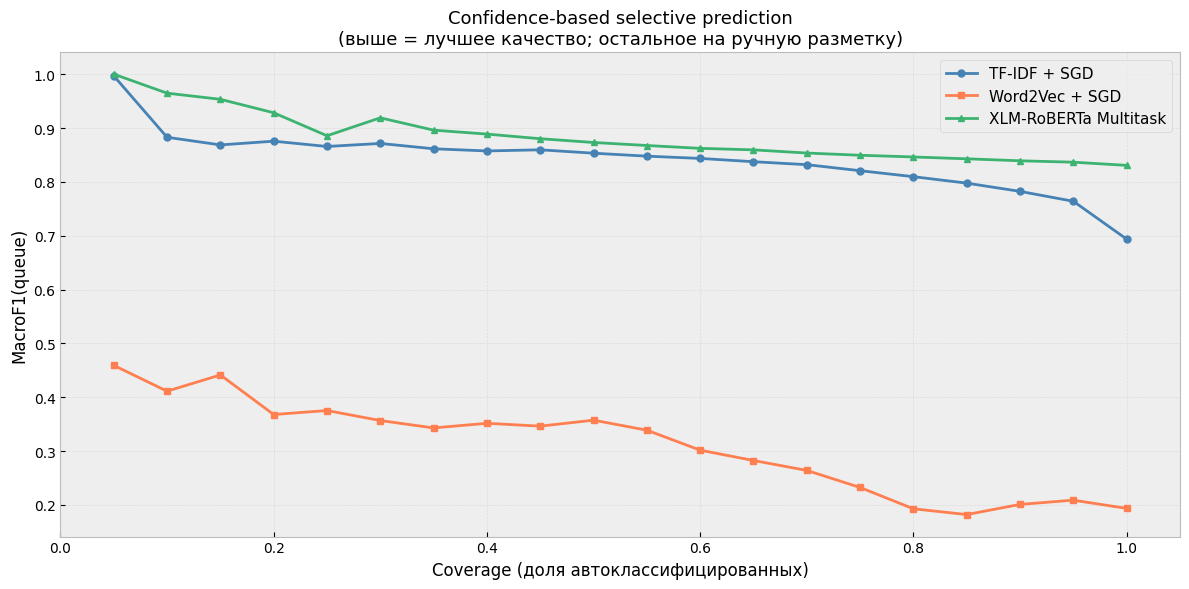


Key coverage points (MacroF1 on queue):
Coverage TF-IDF + SGD Word2Vec + SGD XLM-RoBERTa Multitask
     50%       0.8532         0.3574                0.8731
     70%       0.8319         0.2641                0.8535
     80%       0.8096         0.1928                0.8462
     90%       0.7823         0.2010                0.8391
    100%       0.6936         0.1936                0.8306


In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    "TF-IDF + SGD": "steelblue",
    "Word2Vec + SGD": "coral",
    "XLM-RoBERTa Multitask": "mediumseagreen",
}
markers = {"TF-IDF + SGD": "o", "Word2Vec + SGD": "s", "XLM-RoBERTa Multitask": "^"}

for name, conf_df in all_conf_curves.items():
    ax.plot(
        conf_df["coverage"],
        conf_df["MacroF1(queue)"],
        f"{markers.get(name, 'o')}-",
        label=name,
        color=colors.get(name, "gray"),
        linewidth=2,
        markersize=5,
    )

ax.set_xlabel("Coverage (доля автоклассифицированных)", fontsize=12)
ax.set_ylabel("MacroF1(queue)", fontsize=12)
ax.set_title(
    "Confidence-based selective prediction\n"
    "(выше = лучшее качество; остальное на ручную разметку)",
    fontsize=13,
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

print("\nKey coverage points (MacroF1 on queue):")
key_coverages = [0.5, 0.7, 0.8, 0.9, 1.0]
rows = []
for cov in key_coverages:
    row = {"Coverage": f"{cov:.0%}"}
    for name, conf_df in all_conf_curves.items():
        val = conf_df.loc[conf_df["coverage"] == round(cov, 2), "MacroF1(queue)"]
        row[name] = f"{val.values[0]:.4f}" if len(val) > 0 else "N/A"
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

---

## Ключевые наблюдения

- **TF-IDF + SGDClassifier** демонстрирует достойный результат при минимальных вычислительных затратах. Эффективность обеспечивается за счёт n-gram признаков, которые улавливают локальные паттерны в тексте.

- **Word2Vec + SGDClassifier** показывает умеренные метрики. Основной недостаток подхода - усреднение векторов слов, из-за чего теряется информация о последовательности и синтаксической структуре.

- **XLM-RoBERTa Multitask** достигает наивысшего качества. Преимущества: контекстуальные эмбеддинги, учитывающие окружение токенов, и многозадачное обучение, позволяющее модели находить общие закономерности между задачами `queue`, `priority` и `type`.